In [ ]:
!pip install -q \
transformers \
accelerate \
bitsandbytes \
sentencepiece \
einops \
scipy \
sympy \
numpy \
matplotlib \
pandas
# !pip install -q -U transformers bitsandbytes accelerate sympy scipy numpy

In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

In [ ]:
# !pip install -q tiktoken

Version 1


Version 2

In [ ]:
"""
MathAgent — full experiment runner for the ICA 2026 paper.

Runs THREE experiments across multiple open-source models:
  1. FULL PIPELINE   — Planner -> Hypothesis -> Critic, with the repair/feedback loop
                        (up to `max_loops` retries when validation fails).
  2. ABLATION         — Planner -> Hypothesis -> Critic, but Hypothesis gets exactly ONE
                        shot (no repair loop). The Critic still scores the result, but its
                        feedback is never shown to the model. This isolates how much the
                        repair loop itself contributes vs. a naive one-shot agent pipeline.

Metrics logged per run: success (V_M==1.0), final V_M, iterations to converge (full only),
per-check pass/fail breakdown, wall-clock seconds, planning-retry counts, JSON-parse-failure
counts (planning & hypothesis phases separately), whether the very first hypothesis already
passed ("accepted_first_try"), the full V_M trajectory across iterations, and a repair-efficiency
score. Results are written to `full_experiment_results.json` and a flattened
`full_experiment_results.csv` for easy plotting/tables in the paper.

NOTE ON SCOPE: this file focuses on generating clean, complete per-run data. Some of the
downstream analyses you might want (error-transition Sankey diagrams / heatmaps, radar plots,
convergence-rate-by-model bar charts, etc.) are better done as a separate plotting script that
consumes full_experiment_results.json / .csv, since they don't require re-running the models.
Everything those plots would need (per-iteration indicators, per-iteration feedback text,
planning/hypothesis failure counts) is already captured in the JSON below.
"""

import os
import re
import gc
import csv
import json
import time
import math
import hashlib
import signal
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
from sympy.abc import _clash
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# =====================================================================
# 0. CONFIG — models & benchmark systems
# =====================================================================
# Four models spanning: math-specialized, general-purpose, code-specialized, and
# reasoning-specialized. DeepSeek-R1-Distill-Qwen-7B is a strong open reasoning model and
# gives a much more informative comparison axis for a paper about mathematical reasoning +
# repair than another Qwen variant would.
MODEL_IDS = [
    "Qwen/Qwen2.5-Math-7B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-Coder-7B-Instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]

BENCHMARK_PROBLEMS = {
    "SIR_Epidemic": (
        "Model a closed-system epidemic where susceptible individuals (S) contract a virus "
        "from infected individuals (I) and recover (R) with immunity."
    ),
    "Lotka_Volterra": (
        "Model a classic predator-prey system where prey (x) grows exponentially and predator (y) "
        "decays exponentially in the absence of the other."
    ),
    "Damped_Harmonic_Oscillator": (
        "Model a linear physical system containing mass, spring constants, and dampening friction forces."
    ),
    "SEIR_Epidemic": (
        "Model a closed-system epidemic with an incubation period: susceptible (S) individuals "
        "become exposed (E) but not yet infectious, exposed individuals become infectious (I), "
        "and infectious individuals recover with immunity (R)."
    ),
    "Van_der_Pol_Oscillator": (
        "Model a nonlinear electrical circuit oscillator with nonlinear damping that pumps energy "
        "in at low amplitude and removes it at high amplitude, producing a stable limit cycle."
    ),
    "Logistic_Growth": (
        "Model a single population (N) that grows toward a carrying capacity, slowing its growth "
        "rate as it approaches that limit."
    ),
    "Lorenz_Attractor": (
        "Model the Lorenz chaotic attractor consisting of three coupled nonlinear differential "
        "equations describing atmospheric convection."
    ),
    "Damped_Pendulum": (
        "Model a damped pendulum using first-order differential equations by introducing angular "
        "velocity as an additional state variable."
    ),
}

# Per-benchmark override for the Critic's relative-eigenvalue stability threshold.
# Rationale: Lorenz is chaotic by construction -- a *correct* model of it can have a locally
# positive-real-part Jacobian eigenvalue at the given initial condition even though the overall
# trajectory stays bounded on the attractor. Using the same threshold=5.0 as e.g. Logistic_Growth
# would likely penalize a physically correct Lorenz model. Treat this default as a starting point;
# tune it against a known-good reference solution before trusting the stability indicator for
# Lorenz results in the paper.
STABILITY_THRESHOLD_OVERRIDES = {
    "Lorenz_Attractor": 50.0,
}

MAX_LOOPS_FULL = 3          # repair-loop iterations for the full pipeline
PLANNING_MAX_ATTEMPTS = 3   # formatting-retry attempts (not a physics ablation axis)
NUM_TRIALS = 2              # independent trials per (model, system, mode), for mean/std reporting.
                             # Increase to 3 if your compute budget allows -- reduces to 1 for a quick smoke test.
CACHE_DIR = "llm_cache_full_experiment"
os.makedirs(CACHE_DIR, exist_ok=True)

# =====================================================================
# 1. MODEL LOAD / UNLOAD (sequential, to fit one 7B model in GPU memory at a time)
# =====================================================================
def load_model(model_id):
    print(f"\n{'=' * 70}\nLoading {model_id} ...\n{'=' * 70}")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=bnb_config, device_map="auto", low_cpu_mem_usage=True
    )
    print(f"Loaded {model_id}.")
    return tokenizer, model


def unload_model(tokenizer, model):
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()


# =====================================================================
# 2. LLM CALL + CACHE (cache key includes model_id so models never collide)
# =====================================================================
def ask_llm(tokenizer, model, prompt, system_instruction, max_new_tokens=1024, temperature=0.1):
    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    generated_ids = model.generate(
        **model_inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=True
    )
    generated_ids = [out[len(inp):] for inp, out in zip(model_inputs.input_ids, generated_ids)]
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


def ask_llm_cached(tokenizer, model, model_id, prompt, system_instruction, max_new_tokens=1024, temperature=0.1, cache_salt=0):
    payload = f"{model_id}|||{prompt}|||{system_instruction}|||{max_new_tokens}|||{temperature}|||{cache_salt}"
    key = hashlib.sha256(payload.encode("utf-8")).hexdigest()
    cache_path = os.path.join(CACHE_DIR, f"{key}.txt")
    if os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            return f.read()
    response = ask_llm(tokenizer, model, prompt, system_instruction, max_new_tokens, temperature)
    with open(cache_path, "w", encoding="utf-8") as f:
        f.write(response)
    return response


# =====================================================================
# 3. TIMEOUT CONTROLS
# =====================================================================
class TimeoutException(Exception):
    pass


def _timeout_handler(signum, frame):
    raise TimeoutException("Integration timed out!")


if os.name != "nt":
    signal.signal(signal.SIGALRM, _timeout_handler)


# =====================================================================
# 4. SCIENTIFIC CRITIC — V(M) evaluator (scale-aware stability check)
# =====================================================================
class ScientificCritic:
    def __init__(self, state_variables, parameters, expected_conservation=None, stability_threshold=5.0):
        self.state_var_names = state_variables
        self.param_names = parameters
        self.expected_conservation = expected_conservation
        self.stability_threshold = stability_threshold
        self.state_vars = [sp.Symbol(v) for v in state_variables]
        self.params = {p: sp.Symbol(p) for p in parameters}
        self.local_dict = {}
        self.local_dict.update(_clash)
        for var_sym in self.state_vars:
            self.local_dict[var_sym.name] = var_sym
        for param_name, param_sym in self.params.items():
            self.local_dict[param_name] = param_sym

    def evaluate_system(self, proposed_equations, parameter_values, y0, t_span=(0, 5)):
        feedback = []
        indicators = {"syntax": 0, "variable": 0, "conservation": 0, "stability": 0, "physical": 0}

        # 1. Syntax
        parsed_eqs = {}
        syntax_failed = False
        for var in self.state_var_names:
            if var not in proposed_equations:
                feedback.append(f"Syntax Error: Missing equation for state variable '{var}'.")
                syntax_failed = True
                continue
            eq_str = proposed_equations[var]
            try:
                parsed_eqs[sp.Symbol(var)] = sp.sympify(eq_str, locals=self.local_dict)
            except Exception as e:
                feedback.append(f"Syntax Error: Failed to parse equation for '{var}': '{eq_str}'. Error: {str(e)}")
                syntax_failed = True
        if not syntax_failed:
            indicators["syntax"] = 1
        else:
            return self._compile_metrics(indicators, feedback)

        # 2. Variable boundaries
        var_fail = False
        allowed_symbols = set(self.state_vars).union(set(self.params.values()))
        for var_sym, expr in parsed_eqs.items():
            for sym in expr.free_symbols:
                if sym not in allowed_symbols and sym != sp.Symbol("t"):
                    feedback.append(f"Variable Error: Detected undeclared symbol '{sym}' in equation for '{var_sym.name}'.")
                    var_fail = True
        if not var_fail:
            indicators["variable"] = 1
        else:
            return self._compile_metrics(indicators, feedback)

        # 3. Every declared parameter has a value
        missing_params = [p for p in self.param_names if p not in parameter_values]
        if missing_params:
            feedback.append(f"Variable Error: No numeric value supplied for parameter(s) {missing_params}.")
            return self._compile_metrics(indicators, feedback)

        # 4. Conservation
        if self.expected_conservation:
            try:
                total_derivative = sum(parsed_eqs[v] for v in self.state_vars)
                simplified = sp.simplify(total_derivative)
                if simplified == 0:
                    indicators["conservation"] = 1
                else:
                    feedback.append(f"Conservation Error: sum of derivatives simplified to {simplified}, not 0.")
            except Exception as e:
                feedback.append(f"Conservation Verification Error: {str(e)}")
        else:
            indicators["conservation"] = 1

        # 5. Scale-aware analytical stability
        try:
            eq_list = [parsed_eqs[v] for v in self.state_vars]
            jacobian = sp.Matrix(eq_list).jacobian(self.state_vars)
            subs_dict = {self.params[p]: float(parameter_values[p]) for p in self.param_names}
            for i, var_sym in enumerate(self.state_vars):
                subs_dict[var_sym] = float(y0[i])
            numerical_jac = jacobian.subs(subs_dict)
            np_jac = np.array(numerical_jac.tolist(), dtype=float)
            eigenvalues = np.linalg.eigvals(np_jac)
            max_real_eigen = np.max(np.real(eigenvalues))

            state_scale = max(1.0, max(abs(v) for v in y0))
            relative_eigen = max_real_eigen / state_scale
            stability_threshold = self.stability_threshold
            if relative_eigen > stability_threshold:
                feedback.append(
                    f"Analytical Stability Error: relative growth rate {relative_eigen:.2f} "
                    f"exceeds threshold {stability_threshold} (raw eigenvalue {max_real_eigen:.2f}, "
                    f"state scale {state_scale:.1f})."
                )
            else:
                indicators["stability"] = 1
        except Exception as e:
            feedback.append(f"Analytical Stability check failed: {str(e)}")

        # 6. Numerical simulation & physical constraints
        try:
            ode_func = [sp.lambdify((self.state_vars, list(self.params.values())), parsed_eqs[v]) for v in self.state_vars]

            def system_solver(t, y):
                param_vals = [float(parameter_values[p]) for p in self.param_names]
                return [fn(y, param_vals) for fn in ode_func]

            t_eval = np.linspace(t_span[0], t_span[1], 50)
            if os.name != "nt":
                signal.alarm(3)
            try:
                sol = solve_ivp(system_solver, t_span, y0, t_eval=t_eval, method="RK45")
                if sol.status == 0:
                    if np.any(sol.y < -1e-5):
                        feedback.append("Physical Constraint Error: dynamic values went negative.")
                    elif np.any(np.isnan(sol.y)) or np.any(np.isinf(sol.y)):
                        feedback.append("Numerical Error: simulation yielded NaN/Inf.")
                    else:
                        indicators["physical"] = 1
                else:
                    feedback.append(f"Numerical Error: ODE solver failed with status code {sol.status}.")
            except TimeoutException:
                feedback.append("Numerical Error: simulation hung and timed out.")
            finally:
                if os.name != "nt":
                    signal.alarm(0)
        except Exception as e:
            feedback.append(f"Simulation execution crashed: {str(e)}")

        return self._compile_metrics(indicators, feedback)

    def _compile_metrics(self, indicators, feedback):
        weights = {"syntax": 0.15, "variable": 0.20, "conservation": 0.25, "stability": 0.20, "physical": 0.20}
        score = sum(indicators[k] * weights[k] for k in indicators)
        return {"V_M": round(score, 2), "passed": score == 1.0, "indicators": indicators, "feedback": feedback}


# =====================================================================
# 5. PROMPTS
# =====================================================================
PLANNING_PROMPT = """You are a Scientific Planner. Analyze the user's modeling request and return a strict JSON payload.

Respond with NOTHING except the JSON code block below. No reasoning, no explanation, no "Let's think step by step", no text before or after the code block. Your entire response must be exactly one ```json code block.

Example response for "Model a predator-prey system":
```json
{
  "state_variables": ["x", "y"],
  "parameters": ["alpha", "beta"],
  "expected_conservation": null,
  "y0": [10.0, 5.0],
  "parameter_values": {"alpha": 0.1, "beta": 0.02}
}
```

IMPORTANT: All dynamics must be expressed as a system of FIRST-ORDER differential equations. If the physical system is naturally second-order (e.g. involves acceleration, like a mass-spring-damper or pendulum: m*x'' + c*x' + k*x = 0), you MUST introduce an auxiliary state variable for the first derivative (e.g. velocity "v") so the system becomes:
  dx/dt = v
  dv/dt = -(c/m)*v - (k/m)*x
List BOTH "x" and "v" in "state_variables" in this case, with an initial value for each in "y0". Never name a state variable after its own derivative (e.g. never use "dx/dt" as a variable name).

Now do the same for the user's request. Every parameter listed in "parameters" MUST have a corresponding numeric value in "parameter_values". Output ONLY the JSON code block.
"""

HYPOTHESIS_PROMPT = """You are an Applied Mathematician. Propose differential equation rate strings for the system.

Respond with NOTHING except the JSON code block below. No reasoning, no step-by-step explanation, no restating the problem, no text before or after the code block. Your entire response must be exactly one ```json code block.

Example response for variables x, y and parameters alpha, beta:
```json
{
  "x": "-alpha*x*y",
  "y": "alpha*x*y - beta*y"
}
```

Now do the same for the given variables and parameters.

Rules:
1. Do not output any Python code, only raw algebraic strings.
2. Use ONLY the declared state variables and constant parameters.
3. Keep physical/biological laws in mind (e.g. conservation of mass, populations cannot spawn out of nowhere).
4. Output ONLY the JSON code block, nothing else.
"""


# =====================================================================
# 6. JSON EXTRACTION (robust to reasoning prose, stray fragments, whitespace in keys)
# =====================================================================
def _find_balanced_json_objects(text):
    candidates = []
    stack = []
    start = None
    for i, ch in enumerate(text):
        if ch == "{":
            if not stack:
                start = i
            stack.append(ch)
        elif ch == "}":
            if stack:
                stack.pop()
                if not stack and start is not None:
                    candidates.append(text[start:i + 1])
                    start = None
    candidates.sort(key=len, reverse=True)
    return candidates


_EXPECTED_PLAN_KEYS = {
    "state_variables", "state_vars", "variables", "parameters", "constant_parameters",
    "params", "expected_conservation", "conservation_laws", "y0", "initial_conditions",
    "initial_states", "parameter_values", "param_values", "default_parameters",
}


def _normalize_dict_keys(d):
    if isinstance(d, dict):
        return {(k.strip() if isinstance(k, str) else k): v for k, v in d.items()}
    return d


def _score_candidate(parsed):
    if not isinstance(parsed, dict):
        return -1
    keys = {k.strip().lower() if isinstance(k, str) else k for k in parsed.keys()}
    return len(keys & _EXPECTED_PLAN_KEYS)


def extract_json_block(llm_output, require_dict=True):
    candidates_raw = []
    candidates_raw += re.findall(r"```json\s*([\s\S]*?)\s*```", llm_output)
    candidates_raw += re.findall(r"```\s*([\s\S]*?)\s*```", llm_output)
    candidates_raw += _find_balanced_json_objects(llm_output)

    best_parsed, best_score = None, -1
    for cand in candidates_raw:
        try:
            parsed = json.loads(cand.strip())
        except Exception:
            continue
        parsed = _normalize_dict_keys(parsed)
        if require_dict and not isinstance(parsed, dict):
            continue
        score = _score_candidate(parsed)
        if score > best_score:
            best_score, best_parsed = score, parsed

    if best_parsed is not None:
        return best_parsed
    raise ValueError(f"JSON extraction failed. Output snippet: {llm_output[:300]}...")


# =====================================================================
# 7. PLANNING PHASE (with formatting-retry + name/shape validation)
# =====================================================================
def run_planning_phase(tokenizer, model, model_id, problem_description, trial=0, max_attempts=PLANNING_MAX_ATTEMPTS, debug=True):
    """Returns (plan_or_None, planning_attempts_used, planning_json_failures).

    planning_attempts_used counts every attempt made (successful or not).
    planning_json_failures counts only attempts that failed because the JSON could not be
    extracted/validated (as opposed to e.g. a network error), so it doubles as a JSON-robustness
    metric for the paper.
    """
    planning_feedback = ""
    json_failures = 0
    attempt = 0
    for attempt in range(1, max_attempts + 1):
        prompt = problem_description
        if planning_feedback:
            prompt += (
                f"\n\nYour previous response could not be parsed as JSON. {planning_feedback} "
                f"Respond with ONLY the JSON code block, nothing else."
            )
        plan_tokens = min(1536 + 512 * (attempt - 1), 3072)
        plan_resp = ask_llm_cached(tokenizer, model, model_id, prompt, PLANNING_PROMPT,
                                    max_new_tokens=plan_tokens, cache_salt=trial)

        try:
            plan = extract_json_block(plan_resp)
            state_vars = plan.get("state_variables") or plan.get("state_vars") or plan.get("variables") or []
            parameters = plan.get("parameters") or plan.get("constant_parameters") or plan.get("params") or []
            y0 = plan.get("y0") or plan.get("initial_conditions") or plan.get("initial_states") or []
            param_values = plan.get("parameter_values") or plan.get("param_values") or plan.get("default_parameters") or {}
            conservation = plan.get("expected_conservation") or plan.get("conservation_laws") or None

            state_vars = [str(v) for v in state_vars]
            parameters = [str(p) for p in parameters]
            y0 = [float(val) for val in y0]
            param_values = {str(k): float(v) for k, v in param_values.items()}

            if not state_vars or not parameters or not y0:
                raise ValueError(f"Plan missing required keys. Got top-level keys: {list(plan.keys())}")

            bad_names = [v for v in state_vars if not v.isidentifier() or v in parameters]
            if bad_names:
                raise ValueError(
                    f"Invalid state variable name(s) {bad_names}. Use plain symbols only "
                    f"(never derivative notation like 'dx/dt')."
                )
            if len(y0) != len(state_vars):
                raise ValueError(f"y0 has {len(y0)} values but there are {len(state_vars)} state variables.")

            return {
                "state_vars": state_vars, "parameters": parameters, "y0": y0,
                "param_values": param_values, "conservation": conservation,
            }, attempt, json_failures
        except Exception as e:
            if debug:
                print(f"    ⚠️ Planning attempt {attempt} failed: {e}")
            planning_feedback = str(e)
            json_failures += 1
            continue
    return None, attempt, json_failures


# =====================================================================
# 8. HYPOTHESIS CALL (single call, used by both full pipeline and ablation)
# =====================================================================
def call_hypothesis(tokenizer, model, model_id, state_vars, parameters, conservation, feedback, temperature, trial=0):
    prompt = f"Variables: {state_vars}\nParameters: {parameters}"
    if conservation:
        prompt += f"\nConservation Constraint: {conservation}"
    if feedback:
        prompt += f"\n\nCRITICAL FIXES REQUIRED FROM LAST RUN:\n{feedback}"
    resp = ask_llm_cached(tokenizer, model, model_id, prompt, HYPOTHESIS_PROMPT,
                           max_new_tokens=1536, temperature=temperature, cache_salt=trial)
    return extract_json_block(resp)


# =====================================================================
# 9. RUNNERS: full pipeline (with repair loop) vs. ablation (single-shot Hypothesis)
# =====================================================================
def run_full_pipeline(tokenizer, model, model_id, problem_description, name, max_loops=MAX_LOOPS_FULL, trial=0):
    t0 = time.time()
    plan, planning_attempts, planning_json_failures = run_planning_phase(
        tokenizer, model, model_id, problem_description, trial=trial
    )
    if plan is None:
        return {"name": name, "mode": "full", "trial": trial, "success": False, "total_iterations": 0,
                "final_V_M": 0.0, "history": [], "wall_time_sec": round(time.time() - t0, 2),
                "failure_stage": "planning", "error": "Planning failed after all retry attempts.",
                "planning_attempts": planning_attempts, "planning_json_failures": planning_json_failures,
                "hypothesis_json_failures": 0, "accepted_first_try": False,
                "vm_trajectory": [], "repair_efficiency": None}

    stability_threshold = STABILITY_THRESHOLD_OVERRIDES.get(name, 5.0)
    feedback, history, success = "", [], False
    hypothesis_json_failures = 0
    critic = ScientificCritic(plan["state_vars"], plan["parameters"], plan["conservation"],
                               stability_threshold=stability_threshold)

    for i in range(1, max_loops + 1):
        temperature = min(0.1 + 0.2 * (i - 1), 0.7)
        try:
            eqs = call_hypothesis(tokenizer, model, model_id, plan["state_vars"], plan["parameters"],
                                   plan["conservation"], feedback, temperature, trial=trial)
        except Exception as e:
            hypothesis_json_failures += 1
            feedback = "Your last output was invalid JSON. Return ONLY valid JSON mapping variable names to equation strings."
            history.append({"iteration": i, "equations": {}, "V_M": 0.0, "feedback": [str(e)]})
            continue

        eval_res = critic.evaluate_system(eqs, plan["param_values"], plan["y0"])
        history.append({"iteration": i, "equations": eqs, "V_M": eval_res["V_M"],
                         "indicators": eval_res["indicators"], "feedback": eval_res["feedback"]})
        if eval_res["passed"]:
            success = True
            break
        feedback = "\n".join(f"- {err}" for err in eval_res["feedback"])

    # Report the BEST candidate seen across the whole loop, not just the last one --
    # temperature escalation on retries can occasionally produce a worse candidate than
    # an earlier attempt, and we don't want to penalize the pipeline for discarding a
    # good earlier guess in favor of a later, worse one.
    final = max(history, key=lambda h: h["V_M"]) if history else {"V_M": 0.0, "indicators": {}}
    vm_trajectory = [h["V_M"] for h in history]
    accepted_first_try = bool(history) and history[0]["V_M"] == 1.0

    # Repair efficiency: average V_M gained per repair iteration, from the first attempt to the
    # best attempt seen. Undefined (None) when there was only one iteration, since there's no
    # repair step to measure.
    if len(history) > 1:
        repair_efficiency = round((final["V_M"] - vm_trajectory[0]) / (len(history) - 1), 4)
    else:
        repair_efficiency = None

    return {
        "name": name, "mode": "full", "trial": trial, "success": success, "total_iterations": len(history),
        "final_V_M": final["V_M"], "final_indicators": final.get("indicators", {}),
        "history": history, "wall_time_sec": round(time.time() - t0, 2),
        "failure_stage": None if success else "hypothesis",
        "planning_attempts": planning_attempts, "planning_json_failures": planning_json_failures,
        "hypothesis_json_failures": hypothesis_json_failures, "accepted_first_try": accepted_first_try,
        "vm_trajectory": vm_trajectory, "repair_efficiency": repair_efficiency,
    }


def run_ablation_no_repair(tokenizer, model, model_id, problem_description, name, trial=0):
    """Same Planner + Critic, but Hypothesis gets exactly ONE shot -- no feedback loop.
    Isolates how much the repair loop itself contributes over a naive one-shot pipeline."""
    t0 = time.time()
    plan, planning_attempts, planning_json_failures = run_planning_phase(
        tokenizer, model, model_id, problem_description, trial=trial
    )
    if plan is None:
        return {"name": name, "mode": "ablation", "trial": trial, "success": False, "total_iterations": 0,
                "final_V_M": 0.0, "history": [], "wall_time_sec": round(time.time() - t0, 2),
                "failure_stage": "planning", "error": "Planning failed after all retry attempts.",
                "planning_attempts": planning_attempts, "planning_json_failures": planning_json_failures,
                "hypothesis_json_failures": 0, "accepted_first_try": False,
                "vm_trajectory": [], "repair_efficiency": None}

    stability_threshold = STABILITY_THRESHOLD_OVERRIDES.get(name, 5.0)
    hypothesis_json_failures = 0
    critic = ScientificCritic(plan["state_vars"], plan["parameters"], plan["conservation"],
                               stability_threshold=stability_threshold)
    try:
        eqs = call_hypothesis(tokenizer, model, model_id, plan["state_vars"], plan["parameters"],
                               plan["conservation"], feedback="", temperature=0.1, trial=trial)
        eval_res = critic.evaluate_system(eqs, plan["param_values"], plan["y0"])
        history = [{"iteration": 1, "equations": eqs, "V_M": eval_res["V_M"],
                    "indicators": eval_res["indicators"], "feedback": eval_res["feedback"]}]
        success = eval_res["passed"]
        final_V_M = eval_res["V_M"]
        final_indicators = eval_res["indicators"]
    except Exception as e:
        hypothesis_json_failures += 1
        history = [{"iteration": 1, "equations": {}, "V_M": 0.0, "feedback": [str(e)]}]
        success, final_V_M, final_indicators = False, 0.0, {}

    return {
        "name": name, "mode": "ablation", "trial": trial, "success": success, "total_iterations": 1,
        "final_V_M": final_V_M, "final_indicators": final_indicators,
        "history": history, "wall_time_sec": round(time.time() - t0, 2),
        "failure_stage": None if success else "hypothesis",
        "planning_attempts": planning_attempts, "planning_json_failures": planning_json_failures,
        "hypothesis_json_failures": hypothesis_json_failures, "accepted_first_try": success,
        "vm_trajectory": [final_V_M], "repair_efficiency": None,
    }


# =====================================================================
# 10. SMALL STATS HELPER
# =====================================================================
def _mean_std_ci95(values):
    """Returns (mean, std, half_width) for a 95% CI using the normal approximation
    (1.96 * std / sqrt(n)). Fine for the trial counts used here as a rough uncertainty band;
    for small NUM_TRIALS treat this as indicative rather than a rigorous interval."""
    arr = np.asarray(values, dtype=float)
    n = len(arr)
    if n == 0:
        return 0.0, 0.0, 0.0
    mean = float(np.mean(arr))
    std = float(np.std(arr, ddof=0))
    half_width = 1.96 * std / math.sqrt(n) if n > 1 else 0.0
    return mean, std, half_width


# =====================================================================
# 11. MAIN EXPERIMENT LOOP
# =====================================================================
def main():
    all_results = []

    for model_id in MODEL_IDS:
        tokenizer, model = load_model(model_id)
        for name, desc in BENCHMARK_PROBLEMS.items():
            for trial in range(NUM_TRIALS):
                print(f"\n🚀 [{model_id}] {name} — full pipeline (trial {trial + 1}/{NUM_TRIALS})")
                full_res = run_full_pipeline(tokenizer, model, model_id, desc, name, trial=trial)
                full_res["model_id"] = model_id
                all_results.append(full_res)
                print(f"   success={full_res['success']} V_M={full_res['final_V_M']} "
                      f"iters={full_res['total_iterations']} first_try={full_res['accepted_first_try']} "
                      f"time={full_res['wall_time_sec']}s")

                print(f"🚀 [{model_id}] {name} — ablation (trial {trial + 1}/{NUM_TRIALS})")
                abl_res = run_ablation_no_repair(tokenizer, model, model_id, desc, name, trial=trial)
                abl_res["model_id"] = model_id
                all_results.append(abl_res)
                # save_results(all_results)
                print(f"   success={abl_res['success']} V_M={abl_res['final_V_M']} time={abl_res['wall_time_sec']}s")

        unload_model(tokenizer, model)

    # --- Save full results (nested, for inspection) ---
    with open("full_experiment_results.json", "w") as f:
        json.dump(all_results, f, indent=2)

    # --- Save flattened CSV (per-trial rows, for tables/plots in the paper) ---
    fieldnames = [
        "model_id", "name", "mode", "trial", "success", "failure_stage", "total_iterations",
        "final_V_M", "wall_time_sec", "planning_attempts", "planning_json_failures",
        "hypothesis_json_failures", "accepted_first_try", "repair_efficiency",
    ]
    indicator_names = ["syntax", "variable", "conservation", "stability", "physical"]
    fieldnames += [f"indicator_{k}" for k in indicator_names]

    with open("full_experiment_results.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in all_results:
            row = {k: r.get(k) for k in [
                "model_id", "name", "mode", "trial", "success", "failure_stage",
                "total_iterations", "final_V_M", "wall_time_sec", "planning_attempts",
                "planning_json_failures", "hypothesis_json_failures", "accepted_first_try",
                "repair_efficiency",
            ]}
            indicators = r.get("final_indicators", {})
            for k in indicator_names:
                row[f"indicator_{k}"] = indicators.get(k)
            writer.writerow(row)

    # --- Aggregate mean/std/95%CI per (model, system, mode) across trials ---
    print("\n\n📊 AGGREGATED RESULTS (mean ± std, 95% CI across trials)")
    agg_rows = []
    for model_id in MODEL_IDS:
        for name in BENCHMARK_PROBLEMS:
            for mode in ["full", "ablation"]:
                subset = [r for r in all_results if r["model_id"] == model_id and r["name"] == name and r["mode"] == mode]
                if not subset:
                    continue
                successes = [1.0 if r["success"] else 0.0 for r in subset]
                vms = [r["final_V_M"] for r in subset]
                iters = [r["total_iterations"] for r in subset]
                first_try = [1.0 if r["accepted_first_try"] else 0.0 for r in subset]
                repair_effs = [r["repair_efficiency"] for r in subset if r["repair_efficiency"] is not None]

                conv_mean, conv_std, conv_ci = _mean_std_ci95(successes)
                vm_mean, vm_std, vm_ci = _mean_std_ci95(vms)
                iter_mean, _, _ = _mean_std_ci95(iters)
                first_try_rate, _, _ = _mean_std_ci95(first_try)
                repair_eff_mean, _, _ = _mean_std_ci95(repair_effs) if repair_effs else (None, None, None)

                agg_rows.append({
                    "model_id": model_id, "name": name, "mode": mode, "n_trials": len(subset),
                    "convergence_rate": round(conv_mean, 2), "convergence_rate_ci95": round(conv_ci, 3),
                    "V_M_mean": round(vm_mean, 2), "V_M_std": round(vm_std, 2), "V_M_ci95": round(vm_ci, 3),
                    "mean_iterations": round(iter_mean, 2),
                    "accepted_first_try_rate": round(first_try_rate, 2),
                    "mean_repair_efficiency": round(repair_eff_mean, 4) if repair_eff_mean is not None else None,
                })
                print(f"  {model_id:40s} {name:24s} {mode:9s} conv={conv_mean:.0%}±{conv_ci:.2f}  "
                      f"V_M={vm_mean:.2f}±{vm_std:.2f} (CI95={vm_ci:.2f})  iters={iter_mean:.1f}  "
                      f"first_try={first_try_rate:.0%}  (n={len(subset)})")

    with open("full_experiment_aggregated.json", "w") as f:
        json.dump(agg_rows, f, indent=2)

    # --- Aggregate convergence rate per model per mode (across ALL systems & trials) ---
    print("\n📊 OVERALL CONVERGENCE RATE BY MODEL & MODE")
    for model_id in MODEL_IDS:
        for mode in ["full", "ablation"]:
            subset = [r for r in all_results if r["model_id"] == model_id and r["mode"] == mode]
            if not subset:
                continue
            rate = sum(r["success"] for r in subset) / len(subset)
            avg_vm = sum(r["final_V_M"] for r in subset) / len(subset)
            avg_planning_attempts = sum(r["planning_attempts"] for r in subset) / len(subset)
            total_hyp_json_failures = sum(r["hypothesis_json_failures"] for r in subset)
            print(f"  {model_id:40s} {mode:10s} convergence={rate:.0%}  avg_V_M={avg_vm:.2f}  "
                  f"avg_planning_attempts={avg_planning_attempts:.2f}  "
                  f"hypothesis_json_failures={total_hyp_json_failures}  (n={len(subset)})")

    print("\n✅ Done. See full_experiment_results.json/csv and full_experiment_aggregated.json")


# if __name__ == "__main__":
#     main()

In [ ]:
# tokenizer, model = load_model("Qwen/Qwen2.5-Coder-7B-Instruct")
# model_id = "Qwen/Qwen2.5-Coder-7B-Instruct"
# tokenizer, model = load_model("Qwen/Qwen2.5-Math-7B-Instruct")
# model_id = "Qwen/Qwen2.5-Math-7B-Instruct"
# tokenizer, model = load_model("Qwen/Qwen2.5-7B-Instruct")
# model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer, model = load_model("deepseek-ai/DeepSeek-R1-Distill-Qwen-7B")
model_id = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"


Loading deepseek-ai/DeepSeek-R1-Distill-Qwen-7B ...


config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/28.1k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Loaded deepseek-ai/DeepSeek-R1-Distill-Qwen-7B.


In [ ]:
"""
MathAgent — debugging/repair benchmark. SELF-CONTAINED, RUNS IMMEDIATELY.

Paste this whole block into a Colab cell AFTER you've already run
mathagent_full_experiment.py's cells in the SAME session (so ScientificCritic,
ask_llm_cached, extract_json_block, HYPOTHESIS_PROMPT are already defined) AND you have
a `tokenizer`, `model`, and `model_id` currently loaded (e.g. from load_model(...)).

This block will actually RUN the benchmark and print/save results -- nothing is gated
behind a function call you have to remember to make.
"""

import json
import time
import copy

# ---- Sanity check: make sure prerequisites are actually in memory ----
_required = ["ScientificCritic", "ask_llm_cached", "extract_json_block", "HYPOTHESIS_PROMPT",
             "tokenizer", "model", "model_id"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise NameError(
        f"Missing: {_missing}. Make sure you've run mathagent_full_experiment.py's cells "
        f"in this session, and that tokenizer/model/model_id are set (e.g. "
        f"tokenizer, model = load_model('Qwen/Qwen2.5-Coder-7B-Instruct'); "
        f"model_id = 'Qwen/Qwen2.5-Coder-7B-Instruct')."
    )
print(f"Prerequisites OK. Running debug benchmark against model_id = {model_id}")

MAX_REPAIR_LOOPS = 3
NUM_DEBUG_TRIALS = 2
DEBUG_CACHE_TRIAL_OFFSET = 1000

# =====================================================================
# 1. SEED SYSTEMS — known-correct equations, independent of any prior LLM run
# =====================================================================
SEED_SYSTEMS = {
    "SIR_Epidemic": {
        "state_vars": ["S", "I", "R"],
        "parameters": ["beta", "gamma"],
        "param_values": {"beta": 0.0003, "gamma": 0.1},
        "y0": [990.0, 10.0, 0.0],
        "conservation": "S + I + R",
        "correct_equations": {
            "S": "-beta*S*I",
            "I": "beta*S*I - gamma*I",
            "R": "gamma*I"
        },
    },

    "SEIR_Epidemic": {
        "state_vars": ["S", "E", "I", "R"],
        "parameters": ["beta", "sigma", "gamma"],
        "param_values": {"beta": 0.0003, "sigma": 0.2, "gamma": 0.1},
        "y0": [990.0, 0.0, 10.0, 0.0],
        "conservation": "S + E + I + R",
        "correct_equations": {
            "S": "-beta*S*I",
            "E": "beta*S*I - sigma*E",
            "I": "sigma*E - gamma*I",
            "R": "gamma*I"
        },
    },

    "Lotka_Volterra": {
        "state_vars": ["x", "y"],
        "parameters": ["alpha", "beta", "delta", "gamma"],
        "param_values": {"alpha": 0.1, "beta": 0.02, "delta": 0.01, "gamma": 0.1},
        "y0": [40.0, 9.0],
        "conservation": None,
        "correct_equations": {
            "x": "alpha*x - beta*x*y",
            "y": "delta*x*y - gamma*y"
        },
    },

    "Logistic_Growth": {
        "state_vars": ["N"],
        "parameters": ["r", "K"],
        "param_values": {"r": 0.2, "K": 1000.0},
        "y0": [50.0],
        "conservation": None,
        "correct_equations": {
            "N": "r*N*(1 - N/K)"
        },
    },

    "Damped_Harmonic_Oscillator": {
        "state_vars": ["x", "v"],
        "parameters": ["m", "c", "k"],
        "param_values": {"m": 1.0, "c": 0.3, "k": 2.0},
        "y0": [1.0, 0.0],
        "conservation": None,
        "correct_equations": {
            "x": "v",
            "v": "(-c*v - k*x)/m"
        },
    },

    "Van_der_Pol_Oscillator": {
        "state_vars": ["x", "v"],
        "parameters": ["mu"],
        "param_values": {"mu": 2.0},
        "y0": [2.0, 0.0],
        "conservation": None,
        "correct_equations": {
            "x": "v",
            "v": "mu*(1 - x**2)*v - x"
        },
    },

    "Lorenz_Attractor": {
        "state_vars": ["x", "y", "z"],
        "parameters": ["sigma", "rho", "beta"],
        "param_values": {"sigma": 10.0, "rho": 28.0, "beta": 8/3},
        "y0": [1.0, 1.0, 1.0],
        "conservation": None,
        "correct_equations": {
            "x": "sigma*(y - x)",
            "y": "x*(rho - z) - y",
            "z": "x*y - beta*z"
        },
    },

    "Damped_Pendulum": {
        "state_vars": ["theta", "omega"],
        "parameters": ["g", "L", "b"],
        "param_values": {"g": 9.81, "L": 1.0, "b": 0.2},
        "y0": [0.5, 0.0],
        "conservation": None,
        "correct_equations": {
            "theta": "omega",
            "omega": "-(g/L)*sin(theta) - b*omega"
        },
    },
}

# =====================================================================
# 2. ERROR INJECTION FUNCTIONS
# =====================================================================
def inject_sign_flip(seed):
    eqs = copy.deepcopy(seed["correct_equations"])
    target = seed["state_vars"][0]
    eqs[target] = f"-({eqs[target]})"
    return eqs, f"sign-flipped d{target}/dt"


def inject_missing_term(seed):
    eqs = copy.deepcopy(seed["correct_equations"])
    for var in seed["state_vars"]:
        expr = eqs[var]
        if " - " in expr:
            eqs[var] = expr.split(" - ")[0].strip()
            return eqs, f"removed subtracted term from d{var}/dt"
        if " + " in expr:
            eqs[var] = expr.split(" + ")[0].strip()
            return eqs, f"removed added term from d{var}/dt"
    return None, None


def inject_undeclared_variable(seed):
    eqs = copy.deepcopy(seed["correct_equations"])
    target = seed["state_vars"][0]
    eqs[target] = f"({eqs[target]}) * z"
    return eqs, f"injected undeclared symbol 'z' into d{target}/dt"


def inject_instability(seed):
    eqs = copy.deepcopy(seed["correct_equations"])
    param = seed["parameters"][0]
    target = seed["state_vars"][0]
    eqs[target] = eqs[target].replace(param, f"(50*{param})")
    return eqs, f"scaled parameter '{param}' 50x in d{target}/dt (instability injection)"


def inject_semantic_mechanism_swap(seed):
    if seed["state_vars"] != ["S", "I", "R"]:
        return None, None
    eqs = copy.deepcopy(seed["correct_equations"])
    eqs["S"] = "-beta*S*I + gamma*I"
    eqs["R"] = "0"
    return eqs, "swapped recovery mechanism: R flow rerouted to S (mass still conserved)"


def inject_parameter_swap(seed):
    if len(seed["parameters"]) < 2:
        return None, None
    eqs = copy.deepcopy(seed["correct_equations"])
    p1, p2 = seed["parameters"][0], seed["parameters"][1]
    target = seed["state_vars"][0]
    if p1 in eqs[target]:
        eqs[target] = eqs[target].replace(p1, "__TMP__").replace(p2, p1).replace("__TMP__", p2)
        return eqs, f"swapped parameters '{p1}' and '{p2}' in d{target}/dt"
    return None, None


INJECTIONS = {
    "sign_flip": inject_sign_flip,
    "missing_term": inject_missing_term,
    "undeclared_variable": inject_undeclared_variable,
    "instability": inject_instability,
    "semantic_mechanism_swap": inject_semantic_mechanism_swap,
    "parameter_swap": inject_parameter_swap,
}

# =====================================================================
# 3. REPAIR LOOP
# =====================================================================
def call_hypothesis_repair(state_vars, parameters, conservation, broken_eqs, critic_feedback, temperature, trial=0):
    prompt = f"Variables: {state_vars}\nParameters: {parameters}"
    if conservation:
        prompt += f"\nConservation Constraint: {conservation}"
    prompt += (
        f"\n\nThe following proposed equations are INCORRECT:\n{json.dumps(broken_eqs)}\n\n"
        f"A validator found these problems:\n{critic_feedback}\n\n"
        f"Provide CORRECTED equations that fix these specific problems, in the same JSON format."
    )
    resp = ask_llm_cached(tokenizer, model, model_id, prompt, HYPOTHESIS_PROMPT,
                           max_new_tokens=1536, temperature=temperature,
                           cache_salt=DEBUG_CACHE_TRIAL_OFFSET + trial)
    return extract_json_block(resp)


def run_debug_case(seed_name, seed, injection_name, broken_eqs, injection_desc, trial=0):
    t0 = time.time()
    critic = ScientificCritic(seed["state_vars"], seed["parameters"], seed["conservation"])

    eqs = broken_eqs
    history = []
    success = False
    detected_categories = set()

    for i in range(1, MAX_REPAIR_LOOPS + 1):
        eval_res = critic.evaluate_system(eqs, seed["param_values"], seed["y0"])
        failed_categories = [k for k, v in eval_res["indicators"].items() if v == 0]
        detected_categories.update(failed_categories)
        history.append({
            "iteration": i, "equations": eqs, "V_M": eval_res["V_M"],
            "indicators": eval_res["indicators"], "feedback": eval_res["feedback"],
        })
        if eval_res["passed"]:
            success = True
            break

        feedback_text = "\n".join(f"- {err}" for err in eval_res["feedback"])
        temperature = min(0.1 + 0.2 * (i - 1), 0.7)
        try:
            eqs = call_hypothesis_repair(seed["state_vars"], seed["parameters"], seed["conservation"],
                                          eqs, feedback_text, temperature, trial=trial)
        except Exception as e:
            history.append({"iteration": i + 1, "equations": {}, "V_M": 0.0, "feedback": [str(e)]})
            break

    best_V_M = max((h["V_M"] for h in history), default=0.0)
    return {
        "model_id": model_id, "seed_system": seed_name, "injection": injection_name,
        "injection_desc": injection_desc, "trial": trial, "success": success,
        "undetected_by_critic": False, "iterations_to_fix": len(history) if success else None,
        "total_iterations": len(history), "best_V_M": best_V_M,
        "detected_failure_categories": sorted(detected_categories),
        "history": history, "wall_time_sec": round(time.time() - t0, 2),
    }


# =====================================================================
# 4. RUN IT NOW
# =====================================================================
all_debug_results = []
for seed_name, seed in SEED_SYSTEMS.items():
    for injection_name, inject_fn in INJECTIONS.items():
        broken_eqs, injection_desc = inject_fn(seed)
        if broken_eqs is None:
            continue

        sanity_critic = ScientificCritic(seed["state_vars"], seed["parameters"], seed["conservation"])
        sanity_eval = sanity_critic.evaluate_system(broken_eqs, seed["param_values"], seed["y0"])
        if sanity_eval["passed"]:
            print(f"  ⚠️ {seed_name}/{injection_name}: Critic did NOT detect this injected error "
                  f"(recorded as undetected_by_critic).")
            for trial in range(NUM_DEBUG_TRIALS):
                all_debug_results.append({
                    "model_id": model_id, "seed_system": seed_name, "injection": injection_name,
                    "injection_desc": injection_desc, "trial": trial,
                    "success": None, "undetected_by_critic": True,
                    "iterations_to_fix": 0, "total_iterations": 0, "best_V_M": 1.0,
                    "detected_failure_categories": [], "history": [], "wall_time_sec": 0.0,
                })
            continue

        for trial in range(NUM_DEBUG_TRIALS):
            print(f"🔧 [{model_id}] {seed_name} / {injection_name} (trial {trial + 1}/{NUM_DEBUG_TRIALS})")
            res = run_debug_case(seed_name, seed, injection_name, broken_eqs, injection_desc, trial=trial)
            all_debug_results.append(res)
            print(f"   success={res['success']} iters={res['total_iterations']} "
                  f"detected={res['detected_failure_categories']} time={res['wall_time_sec']}s")

with open("debug_benchmark_results.json", "w") as f:
    json.dump(all_debug_results, f, indent=2)

detected = [r for r in all_debug_results if not r.get("undetected_by_critic")]
recovery_rate = sum(r["success"] for r in detected) / len(detected) if detected else 0
undetected = [r for r in all_debug_results if r.get("undetected_by_critic")]

print(f"\n📊 Recovery rate (detected bugs): {recovery_rate:.0%}  (n={len(detected)})")
print(f"📊 Undetected by Critic: {len(undetected)} cases")
for r in undetected:
    print(f"   - {r['seed_system']} / {r['injection']}")
print("\n✅ Saved debug_benchmark_results.json")

Prerequisites OK. Running debug benchmark against model_id = deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
🔧 [deepseek-ai/DeepSeek-R1-Distill-Qwen-7B] SIR_Epidemic / sign_flip (trial 1/2)
   success=True iters=2 detected=['conservation'] time=39.75s
🔧 [deepseek-ai/DeepSeek-R1-Distill-Qwen-7B] SIR_Epidemic / sign_flip (trial 2/2)
   success=True iters=2 detected=['conservation'] time=50.55s
🔧 [deepseek-ai/DeepSeek-R1-Distill-Qwen-7B] SIR_Epidemic / missing_term (trial 1/2)
   success=True iters=2 detected=['conservation'] time=63.97s
🔧 [deepseek-ai/DeepSeek-R1-Distill-Qwen-7B] SIR_Epidemic / missing_term (trial 2/2)
   success=True iters=2 detected=['conservation'] time=72.89s
🔧 [deepseek-ai/DeepSeek-R1-Distill-Qwen-7B] SIR_Epidemic / undeclared_variable (trial 1/2)
   success=True iters=2 detected=['conservation', 'physical', 'stability', 'variable'] time=37.02s
🔧 [deepseek-ai/DeepSeek-R1-Distill-Qwen-7B] SIR_Epidemic / undeclared_variable (trial 2/2)
   success=True iters=2 detected=['conse

REPAIR EFFICIENCY (only runs with >1 iteration, i.e. actual repair loop activity)
  Qwen/Qwen2.5-Math-7B-Instruct    Lotka_Volterra             RE=+0.000  iters=3  final_V_M=0.15
  Qwen/Qwen2.5-Math-7B-Instruct    Damped_Harmonic_Oscillator RE=+0.000  iters=3  final_V_M=0.8
  Qwen/Qwen2.5-Math-7B-Instruct    Damped_Harmonic_Oscillator RE=+0.000  iters=3  final_V_M=0.8
  Qwen/Qwen2.5-Math-7B-Instruct    Van_der_Pol_Oscillator     RE=+0.067  iters=3  final_V_M=1.0
  Qwen/Qwen2.5-Math-7B-Instruct    Van_der_Pol_Oscillator     RE=+0.100  iters=2  final_V_M=1.0
  Qwen/Qwen2.5-Math-7B-Instruct    Logistic_Growth            RE=+0.500  iters=2  final_V_M=1.0
  Qwen/Qwen2.5-Math-7B-Instruct    Lorenz_Attractor           RE=+0.000  iters=3  final_V_M=0.8
  Qwen/Qwen2.5-Math-7B-Instruct    Damped_Pendulum            RE=+0.000  iters=3  final_V_M=0.0
  Qwen/Qwen2.5-Math-7B-Instruct    Damped_Pendulum            RE=+0.000  iters=3  final_V_M=0.8
  Qwen/Qwen2.5-7B-Instruct         SIR_Epidemic      

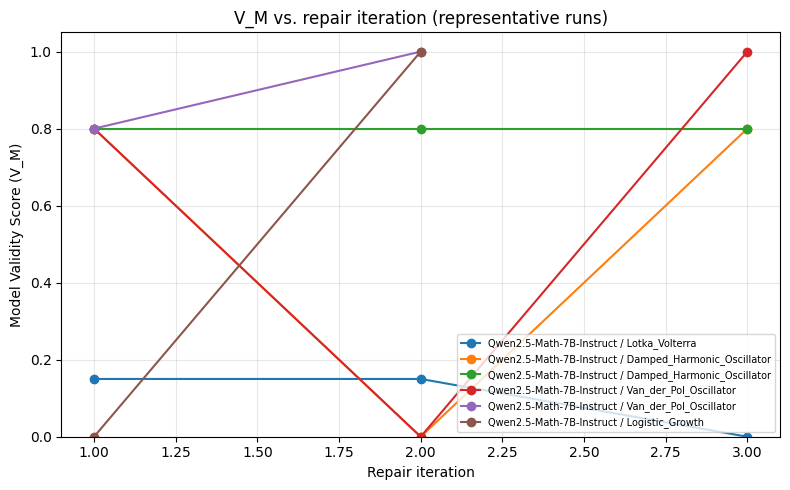

In [ ]:
"""
MathAgent — post-hoc analysis of saved results (no GPU / new model calls needed).

Computes, from full_experiment_results.json:
  1. Repair Efficiency (RE) per run: (final_V_M - first_V_M) / iterations_used.
     A positive RE means the repair loop is making real progress per step; near-zero
     or negative RE flags cases where repair stalled or regressed.
  2. Per-iteration error-fixed / error-introduced trajectory, derived by diffing the
     'indicators' dict between consecutive iterations in each run's history.
  3. A V_M-vs-iteration line plot for a handful of representative runs, saved as PNG --
     the "reviewers love these figures" plot from the feedback.

Run this AFTER mathagent_full_experiment.py has produced full_experiment_results.json.
"""

import json
import matplotlib.pyplot as plt

with open("full_experiment_results.json") as f:
    all_results = json.load(f)


# =====================================================================
# 1. REPAIR EFFICIENCY
# =====================================================================
def compute_repair_efficiency(run):
    history = run.get("history", [])
    if len(history) < 2:
        return None  # no repair happened (converged in 1, or failed immediately)
    first_vm = history[0]["V_M"]
    final_vm = max(h["V_M"] for h in history)  # best achieved, matching the pipeline's own reporting
    iterations_used = len(history)
    return round((final_vm - first_vm) / iterations_used, 3)


print("=" * 70)
print("REPAIR EFFICIENCY (only runs with >1 iteration, i.e. actual repair loop activity)")
print("=" * 70)
efficiency_rows = []
for r in all_results:
    if r["mode"] != "full":
        continue
    re_score = compute_repair_efficiency(r)
    if re_score is None:
        continue
    efficiency_rows.append({
        "model_id": r["model_id"], "name": r["name"], "trial": r.get("trial", 0),
        "repair_efficiency": re_score, "total_iterations": r["total_iterations"],
        "final_V_M": r["final_V_M"],
    })
    print(f"  {r['model_id']:32s} {r['name']:26s} RE={re_score:+.3f}  "
          f"iters={r['total_iterations']}  final_V_M={r['final_V_M']}")

with open("repair_efficiency.json", "w") as f:
    json.dump(efficiency_rows, f, indent=2)


# =====================================================================
# 2. PER-ITERATION ERROR-FIXED / ERROR-INTRODUCED TRAJECTORY
# =====================================================================
def diff_indicators(prev_ind, curr_ind):
    fixed, introduced = [], []
    for check in prev_ind:
        prev_val = prev_ind.get(check, 0)
        curr_val = curr_ind.get(check, 0)
        if prev_val == 0 and curr_val == 1:
            fixed.append(check)
        elif prev_val == 1 and curr_val == 0:
            introduced.append(check)
    return fixed, introduced


print("\n" + "=" * 70)
print("PER-ITERATION ERROR TRAJECTORY (checks fixed / newly broken between steps)")
print("=" * 70)
trajectory_rows = []
for r in all_results:
    if r["mode"] != "full" or len(r.get("history", [])) < 2:
        continue
    history = r["history"]
    for i in range(1, len(history)):
        prev_ind = history[i - 1].get("indicators", {})
        curr_ind = history[i].get("indicators", {})
        fixed, introduced = diff_indicators(prev_ind, curr_ind)
        if fixed or introduced:
            row = {
                "model_id": r["model_id"], "name": r["name"], "trial": r.get("trial", 0),
                "from_iteration": history[i - 1]["iteration"], "to_iteration": history[i]["iteration"],
                "checks_fixed": fixed, "checks_newly_broken": introduced,
            }
            trajectory_rows.append(row)
            print(f"  {r['model_id']:32s} {r['name']:26s} iter {row['from_iteration']}->{row['to_iteration']}: "
                  f"fixed={fixed}  newly_broken={introduced}")

with open("error_trajectory.json", "w") as f:
    json.dump(trajectory_rows, f, indent=2)


# =====================================================================
# 3. V_M vs ITERATION PLOT (representative runs)
# =====================================================================
# Pick a handful of interesting runs: prefer ones with >1 iteration so the trajectory
# is visible. Adjust this selection to whichever systems you want to feature in the paper.
candidates = [r for r in all_results if r["mode"] == "full" and len(r.get("history", [])) > 1]
plot_runs = candidates[:6]  # cap at 6 lines so the plot stays readable

if plot_runs:
    plt.figure(figsize=(8, 5))
    for r in plot_runs:
        iterations = [h["iteration"] for h in r["history"]]
        vms = [h["V_M"] for h in r["history"]]
        label = f"{r['model_id'].split('/')[-1]} / {r['name']}"
        plt.plot(iterations, vms, marker="o", label=label)
    plt.xlabel("Repair iteration")
    plt.ylabel("Model Validity Score (V_M)")
    plt.title("V_M vs. repair iteration (representative runs)")
    plt.ylim(0, 1.05)
    plt.legend(fontsize=7, loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("vm_vs_iteration.png", dpi=150)
    print("\n✅ Saved vm_vs_iteration.png")
else:
    print("\n⚠️ No multi-iteration runs found to plot -- check full_experiment_results.json.")

print("\n✅ Analysis complete. See repair_efficiency.json, error_trajectory.json, vm_vs_iteration.png")